<a href="https://colab.research.google.com/github/Vimukthi-Nuwan/Deep_Learning/blob/Experiment/Cat_vs_Dog_Classifier/DL2_Final_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📌 Step 1: Load the necessary libraries

In [ ]:
import os
import time
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tensorflow import keras
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

### 📌 Step 2: Define dataset directory paths

In [ ]:
base_dir = 'dogs-vs-cats-vvsmall'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

train_cat_dir = os.path.join(train_dir, 'cats')  # Training cats directory
train_dog_dir = os.path.join(train_dir, 'dogs')  # Training dogs directory
validation_cat_dir = os.path.join(validation_dir, 'cats')  # Validation cats directory
validation_dog_dir = os.path.join(validation_dir, 'dogs')  # Validation dogs directory

### 📌 Step 3: Display sample image names from each category

In [ ]:
train_cat_names = os.listdir(train_cat_dir)
print(f"First 10 cat names: {train_cat_names[:10]}\n")

train_dog_names = os.listdir(train_dog_dir)
print(f"First 10 dog names : {train_dog_names[:10]}\n")

validation_cat_names = os.listdir(validation_cat_dir)
print(f"First 10 validation cat names : {validation_cat_names[:10]}\n")

validation_dog_names = os.listdir(validation_dog_dir)
print(f"First 10 validation dog names : {validation_dog_names[:10]}")

First 10 cat names: ['cat.2718.jpg', 'cat.1211.jpg', 'cat.1577.jpg', 'cat.952.jpg', 'cat.946.jpg', 'cat.1563.jpg', 'cat.1205.jpg', 'cat.2724.jpg', 'cat.2042.jpg', 'cat.2056.jpg']

First 10 dog names : ['dog.1753.jpg', 'dog.775.jpg', 'dog.1035.jpg', 'dog.1021.jpg', 'dog.2528.jpg', 'dog.761.jpg', 'dog.1747.jpg', 'dog.991.jpg', 'dog.2266.jpg', 'dog.749.jpg']

First 10 validation cat names : ['cat.8553.jpg', 'cat.8547.jpg', 'cat.9117.jpg', 'cat.9103.jpg', 'cat.8590.jpg', 'cat.8584.jpg', 'cat.9329.jpg', 'cat.8989.jpg', 'cat.8751.jpg', 'cat.8745.jpg']

First 10 validation dog names : ['dog.8777.jpg', 'dog.8763.jpg', 'dog.9333.jpg', 'dog.8993.jpg', 'dog.8987.jpg', 'dog.9327.jpg', 'dog.8978.jpg', 'dog.8788.jpg', 'dog.8950.jpg', 'dog.8944.jpg']


### 📌 Step 4: Print total number of images in each category

In [ ]:
print('Total training cat images:', len(os.listdir(train_cat_dir)))
print('Total training dog images:', len(os.listdir(train_dog_dir)))
print('Total validation cat images:', len(os.listdir(validation_cat_dir)))
print('Total validation dog images:', len(os.listdir(validation_dog_dir)))

Total training cat images: 3000
Total training dog images: 3000
Total validation cat images: 900
Total validation dog images: 900


### 📌 Step 5: Display sample images from the dataset

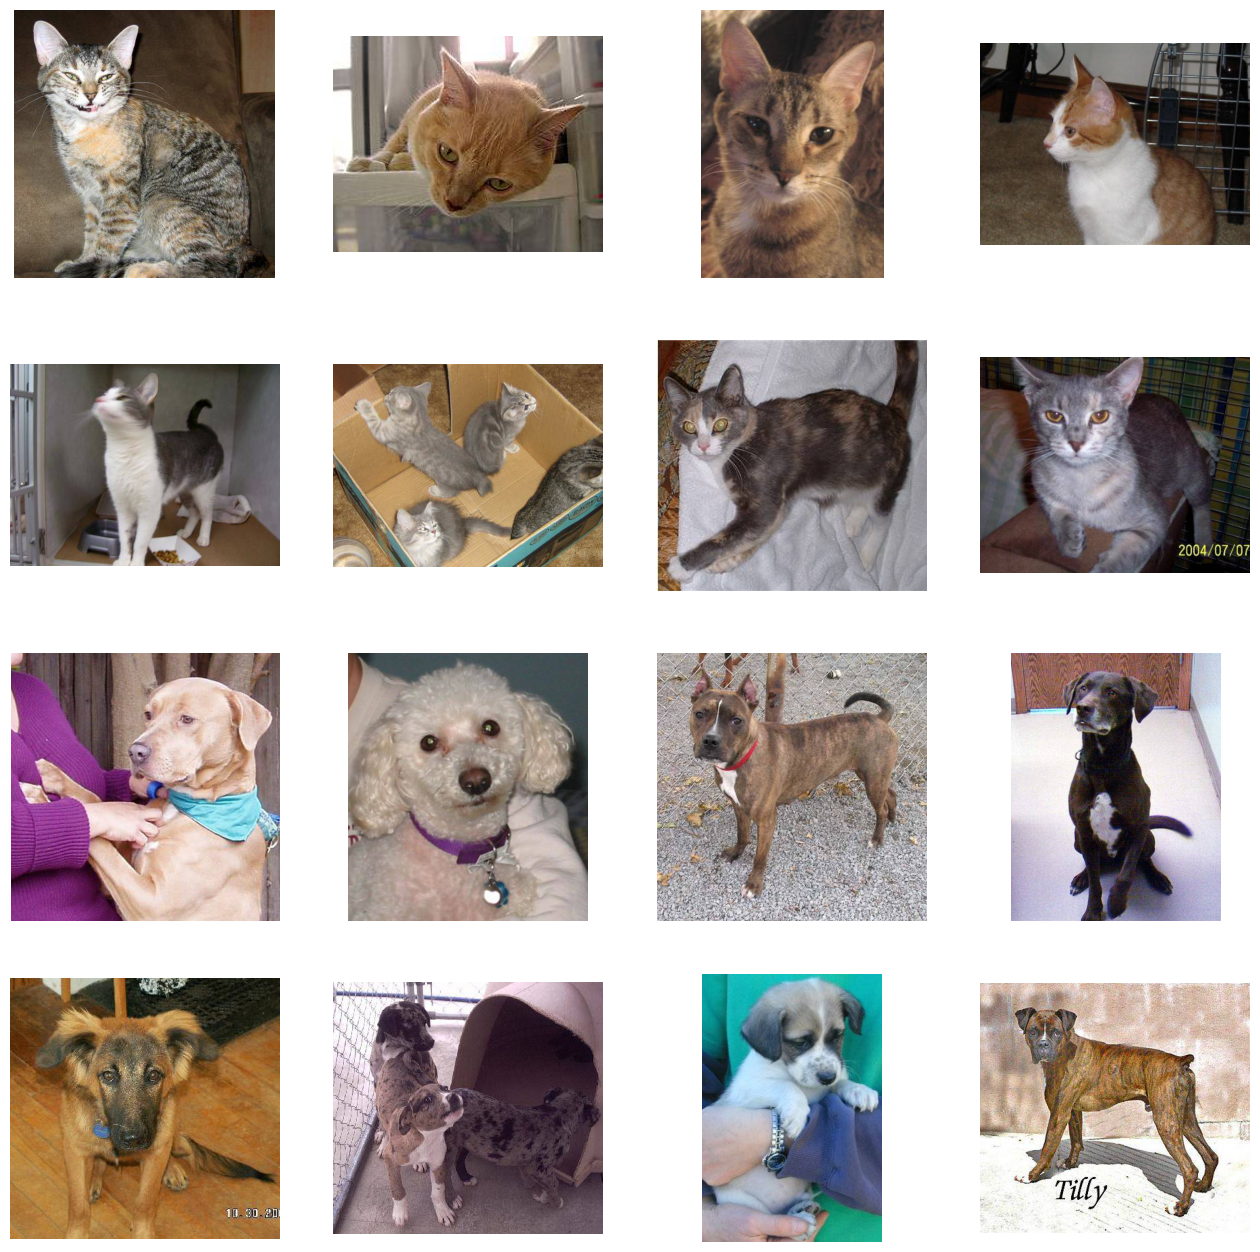

In [ ]:
nrows = 4
ncols = 4
pic_index = 0

fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

pic_index += 8

# Get 8 sample cat images
next_cat_pix = [os.path.join(train_cat_dir, fname) for fname in train_cat_names[pic_index-8:pic_index]]

# Get 8 sample dog images
next_dog_pix = [os.path.join(train_dog_dir, fname) for fname in train_dog_names[pic_index-8:pic_index]]

# Display images in a grid
for i, img_path in enumerate(next_cat_pix + next_dog_pix):
    sp = plt.subplot(nrows, ncols, i + 1)
    sp.axis('Off')
    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

### 📌 Step 6: Define Image Augmentation and Rescaling

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values (0-1)
    rotation_range=5,        # Small rotations (±5 degrees)
    width_shift_range=0.05,  # Horizontal shift (±5% of width)
    height_shift_range=0.05, # Vertical shift (±5% of height)
    shear_range=0.05,        # Shear transformation
    zoom_range=0.05,         # Zoom in/out
    horizontal_flip=True,    # Randomly flip images horizontally
    fill_mode='nearest'      # Fill missing pixels after transformation
)

# Validation images are only rescaled (no augmentation)
validation_datagen = ImageDataGenerator(rescale=1./255)

### 📌 Step 7: Load Images from Directory

In [ ]:
train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(300, 300),  # Resize images to 300x300
        batch_size=32,           # Set batch size
        class_mode='binary'      # Binary classification (dog vs cat)
)

validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(300, 300),
        batch_size=32,
        class_mode='binary'
)

Found 6000 images belonging to 2 classes.
Found 1800 images belonging to 2 classes.


### 📌 Step 8: Define the VGG16 Model (Pre-trained)

In [ ]:
def build_vgg16_model(input_shape=(300, 300, 3)):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu6', kernel_regularizer=keras.regularizers.l2(0.00005)),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    return model

# Create VGG16 model
vgg16_model = build_vgg16_model()

# Display model architecture
vgg16_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 9, 9, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### 📌 Step 9: Compile the Model

In [ ]:
vgg16_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

### 📌 Step 10: Define Learning Rate Scheduler

In [ ]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

### 📌 Step 11: Train the Model

In [ ]:
start_time = time.time()

history = vgg16_model.fit(
    train_generator,
    epochs=60,
    validation_data=validation_generator,
    batch_size=32,
    callbacks=[lr_scheduler]
)

end_time = time.time()
seconds = end_time - start_time
print(f"Time taken: {seconds/60:.2f} minutes to train model.")

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 486s 3s/step - accuracy: 0.5315 - loss: 0.7126 - val_accuracy: 0.8000 - val_loss: 0.5953 - learning_rate: 1.0000e-04
Epoch 2/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 487s 3s/step - accuracy: 0.7064 - loss: 0.6029 - val_accuracy: 0.8356 - val_loss: 0.5120 - learning_rate: 1.0000e-04
Epoch 3/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 487s 3s/step - accuracy: 0.7907 - loss: 0.5245 - val_accuracy: 0.8594 - val_loss: 0.4517 - learning_rate: 1.0000e-04
Epoch 4/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 487s 3s/step - accuracy: 0.8226 - loss: 0.4765 - val_accuracy: 0.8706 - val_loss: 0.4047 - learning_rate: 1.0000e-04
Epoch 5/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 487s 3s/step - accuracy: 0.8396 - loss: 0.4262 - val_accuracy: 0.8828 - val_loss: 0.3648 - learning_rate: 1.0000e-04
Epoch 6/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 486s 3s/step - accuracy: 0.8580 - loss: 0.3871 - val_accuracy: 0.8922 - val_loss: 0.3374 - learning_rate: 1.0000e-04
Epoch 7/60
188/188 ━━━━━━━━━━━━━━━━━━━━ 484s 3s/step - acc

### 📌 Step 12: Plot Training History (Accuracy & Loss)

🔹 Plot Training and Validation Accuracy Over Epochs

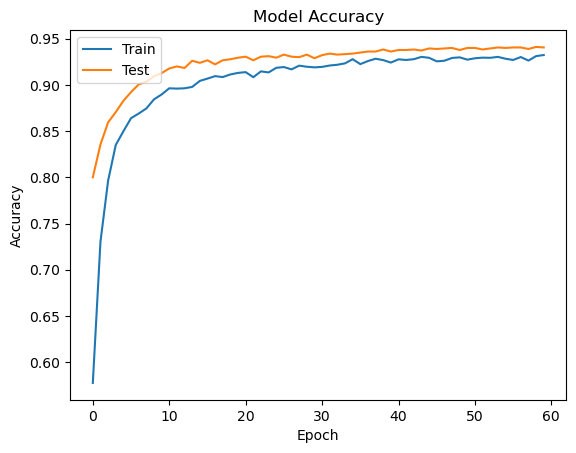

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

🔹 Plot Training and Validation Loss Over Epochs

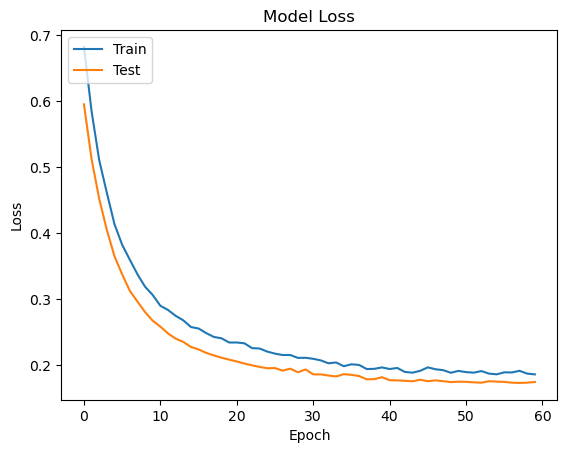

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### 📌 Step 13: Evaluate Model Performance on Validation Set

In [ ]:
val_loss, val_acc = vgg16_model.evaluate(validation_generator)
print(f"VGG16 Model Validation Accuracy : {val_acc:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.9405 - loss: 0.1669
VGG16 Model Validation Accuracy : 0.9406
